# Online Retail EDA

## Exploratory Data Analysis for Data Engineering Portfolio

This notebook explores the cleaned Online Retail dataset generated by the ingestion stage of the pipeline.

The goal is to validate data quality, understand the dataset, and identify business insights before building the staging and data warehouse layers.

## Dataset Used

`data/processed/cleaned_sales.parquet`

## Main Objectives

1. Load the cleaned dataset
2. Review structure and data types
3. Validate missing values and duplicates
4. Analyze sales behavior
5. Identify top products, customers, and countries
6. Generate portfolio-ready insights


## 1. Import Libraries

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


Matplotlib is building the font cache; this may take a moment.


## 2. Define Project Paths

The notebook uses relative paths based on the project root structure.

Expected structure:

```text
OnlineRetail/
├── data/
│   ├── raw/
│   └── processed/
├── output/
├── db/
├── logs/
├── notebooks/
├── scripts/
├── run_pipeline.py
└── run_pipeline.sh
```


In [2]:
# If this notebook is inside the notebooks/ folder, parent.parent points to the project root
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = BASE_DIR / "data" / "processed" / "cleaned_sales.parquet"

print("Project root:", BASE_DIR)
print("Dataset path:", DATA_PATH)


Project root: /Users/linamarcela.franco/PycharmProjects/Bootcamp/OnlineRetail
Dataset path: /Users/linamarcela.franco/PycharmProjects/Bootcamp/OnlineRetail/data/processed/cleaned_sales.parquet


## 3. Load Cleaned Dataset

In [3]:
df = pd.read_parquet(DATA_PATH)

print("Dataset loaded successfully")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()


Dataset loaded successfully
Rows: 535,383
Columns: 8


,invoiceno,stockcode,description,quantity,unitprice,invoicedate,customerid,country
0,536365,85123A,White Hanging Heart T-Light Holder,6,2.55,2010-12-01 08:26:00,17850,United Kingdom
1,536365,71053,White Metal Lantern,6,3.39,2010-12-01 08:26:00,17850,United Kingdom
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2.75,2010-12-01 08:26:00,17850,United Kingdom
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,3.39,2010-12-01 08:26:00,17850,United Kingdom
4,536365,84029E,Red Woolly Hottie White Heart.,6,3.39,2010-12-01 08:26:00,17850,United Kingdom


## 4. Dataset Structure

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535383 entries, 0 to 535382
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    535383 non-null  string        
 1   stockcode    535383 non-null  string        
 2   description  535383 non-null  string        
 3   quantity     535383 non-null  int64         
 4   unitprice    535383 non-null  float64       
 5   invoicedate  535383 non-null  datetime64[ns]
 6   customerid   535383 non-null  string        
 7   country      535383 non-null  string        
dtypes: datetime64[ns](1), float64(1), int64(1), string(5)
memory usage: 32.7 MB


In [5]:
df.dtypes


invoiceno      string[python]
stockcode      string[python]
description    string[python]
quantity                int64
unitprice             float64
invoicedate    datetime64[ns]
customerid     string[python]
country        string[python]
dtype: object

## 5. Basic Data Quality Checks

In [6]:
quality_summary = pd.DataFrame({
    "column": df.columns,
    "missing_values": df.isna().sum().values,
    "missing_percentage": (df.isna().mean().values * 100).round(2),
    "unique_values": df.nunique(dropna=False).values,
    "data_type": df.dtypes.astype(str).values
})

quality_summary


,column,missing_values,missing_percentage,unique_values,data_type
0,invoiceno,0,0.0,25850,string
1,stockcode,0,0.0,4070,string
2,description,0,0.0,4189,string
3,quantity,0,0.0,721,int64
4,unitprice,0,0.0,1629,float64
5,invoicedate,0,0.0,23219,datetime64[ns]
6,customerid,0,0.0,4359,string
7,country,0,0.0,35,string


In [7]:
duplicate_rows = df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_rows:,}")


Exact duplicate rows: 0


## 6. Convert Date Column

This ensures the invoice date is treated as a timestamp for time-based analysis.


In [8]:
df["invoicedate"] = pd.to_datetime(df["invoicedate"], errors="coerce")

print("Invalid invoice dates:", df["invoicedate"].isna().sum())
print("Date range:")
print("Min date:", df["invoicedate"].min())
print("Max date:", df["invoicedate"].max())


Invalid invoice dates: 0
Date range:
Min date: 2010-12-01 08:26:00
Max date: 2011-12-10 09:01:00


## 7. Numeric Field Validation

In [9]:
numeric_validation = {
    "negative_quantity_rows": int((df["quantity"] < 0).sum()),
    "zero_quantity_rows": int((df["quantity"] == 0).sum()),
    "negative_unitprice_rows": int((df["unitprice"] < 0).sum()),
    "zero_unitprice_rows": int((df["unitprice"] == 0).sum())
}

numeric_validation


{'negative_quantity_rows': 10576,
 'zero_quantity_rows': 0,
 'negative_unitprice_rows': 2,
 'zero_unitprice_rows': 2510}

## 8. Create Analytical Columns for EDA

This notebook can create temporary analytical columns for exploration.  
These columns are not necessarily part of the final cleaned dataset.


In [10]:
df["sales_amount"] = df["quantity"] * df["unitprice"]
df["invoice_date"] = df["invoicedate"].dt.date
df["year_month"] = df["invoicedate"].dt.to_period("M").astype(str)

df[["quantity", "unitprice", "sales_amount", "invoice_date", "year_month"]].head()


,quantity,unitprice,sales_amount,invoice_date,year_month
0,6,2.55,15.30,2010-12-01,2010-12
1,6,3.39,20.34,2010-12-01,2010-12
2,8,2.75,22.00,2010-12-01,2010-12
3,6,3.39,20.34,2010-12-01,2010-12
4,6,3.39,20.34,2010-12-01,2010-12


## 9. General Business KPIs

In [11]:
total_revenue = df["sales_amount"].sum()
total_transactions = df["invoiceno"].nunique()
total_products = df["stockcode"].nunique()
total_customers = df["customerid"].nunique()
total_countries = df["country"].nunique()

kpi_summary = pd.DataFrame({
    "metric": [
        "Total Revenue",
        "Unique Invoices",
        "Unique Products",
        "Unique Customers",
        "Unique Countries"
    ],
    "value": [
        round(total_revenue, 2),
        total_transactions,
        total_products,
        total_customers,
        total_countries
    ]
})

kpi_summary


,metric,value
0,Total Revenue,9699913.57
1,Unique Invoices,25850.00
2,Unique Products,4070.00
3,Unique Customers,4359.00
4,Unique Countries,35.00


## 10. Monthly Sales Trend

In [12]:
monthly_sales = (
    df.groupby("year_month", as_index=False)
      .agg(total_sales=("sales_amount", "sum"),
           total_orders=("invoiceno", "nunique"))
      .sort_values("year_month")
)

monthly_sales.head()


,year_month,total_sales,total_orders
0,2010-12,746360.080,2024
1,2011-01,557803.480,1474
2,2011-02,495241.700,1392
3,2011-03,678504.650,1980
4,2011-04,491584.341,1741


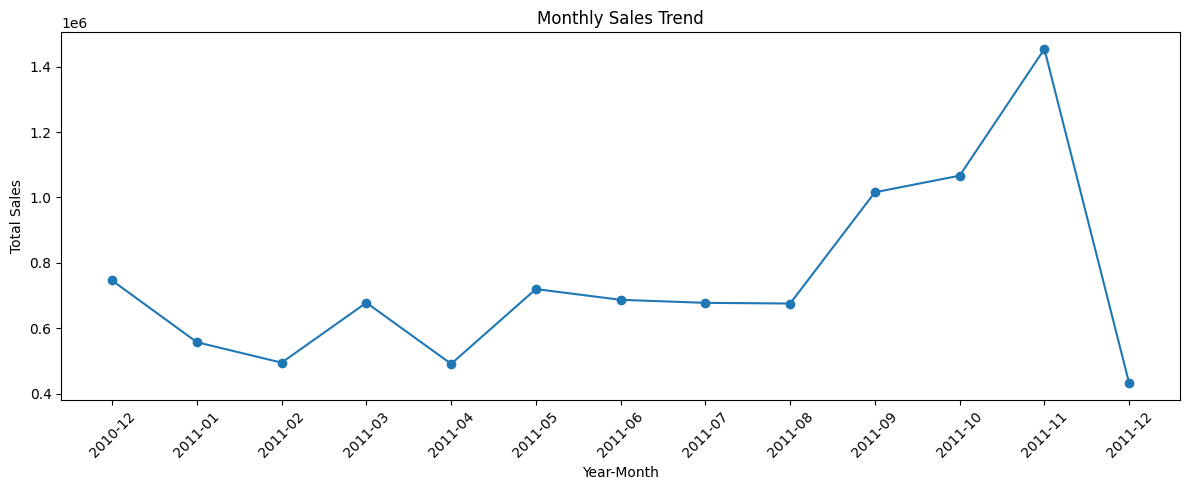

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["year_month"], monthly_sales["total_sales"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Year-Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 11. Top 10 Countries by Sales

In [14]:
top_countries = (
    df.groupby("country", as_index=False)
      .agg(total_sales=("sales_amount", "sum"),
           total_orders=("invoiceno", "nunique"))
      .sort_values("total_sales", ascending=False)
      .head(10)
)

top_countries


,country,total_sales,total_orders
33,United Kingdom,8167143.884,23495
22,Netherlands,284661.540,101
9,Eire,262993.380,360
12,Germany,221509.470,603
11,France,197317.110,461
0,Australia,137009.770,69
31,Switzerland,56363.050,74
29,Spain,54756.030,105
3,Belgium,40910.960,119
30,Sweden,36585.410,46


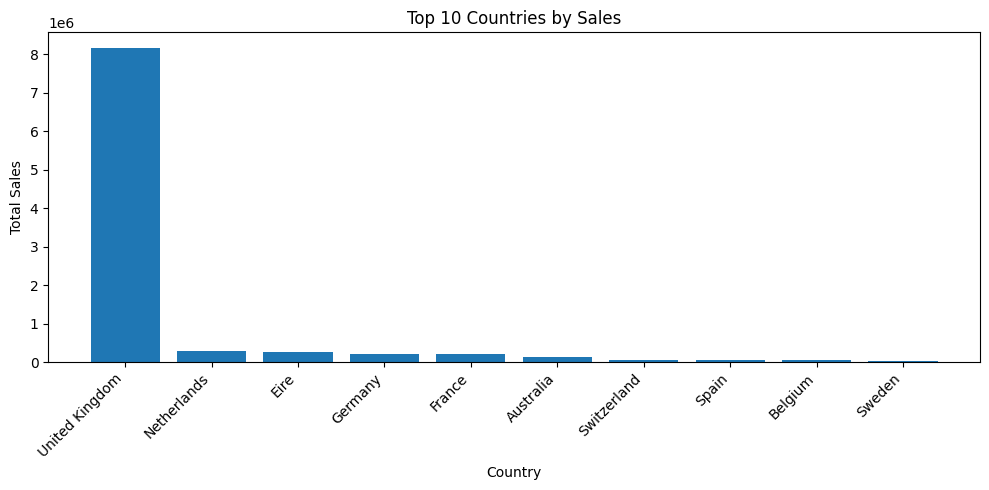

In [15]:
plt.figure(figsize=(10, 5))
plt.bar(top_countries["country"], top_countries["total_sales"])
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 12. Top 10 Products by Sales

In [16]:
top_products = (
    df.groupby(["stockcode", "description"], as_index=False)
      .agg(total_sales=("sales_amount", "sum"),
           total_quantity=("quantity", "sum"))
      .sort_values("total_sales", ascending=False)
      .head(10)
)

top_products


,stockcode,description,total_sales,total_quantity
5727,DOT,Dotcom Postage,206245.48,707
1930,22423,Regency Cakestand 3 Tier,163916.19,12961
3867,47566,Party Bunting,98045.88,17970
5091,85123A,White Hanging Heart T-Light Holder,97341.34,34898
5058,85099B,Jumbo Bag Red Retrospot,91715.09,47010
2808,23084,Rabbit Night Light,66634.59,30618
5732,POST,Postage,66089.64,2994
1543,22086,Paper Chain Kit 50'S Christmas,63609.04,18840
4749,84879,Assorted Colour Bird Ornament,58741.72,36252
4158,79321,Chilli Lights,53746.66,10225


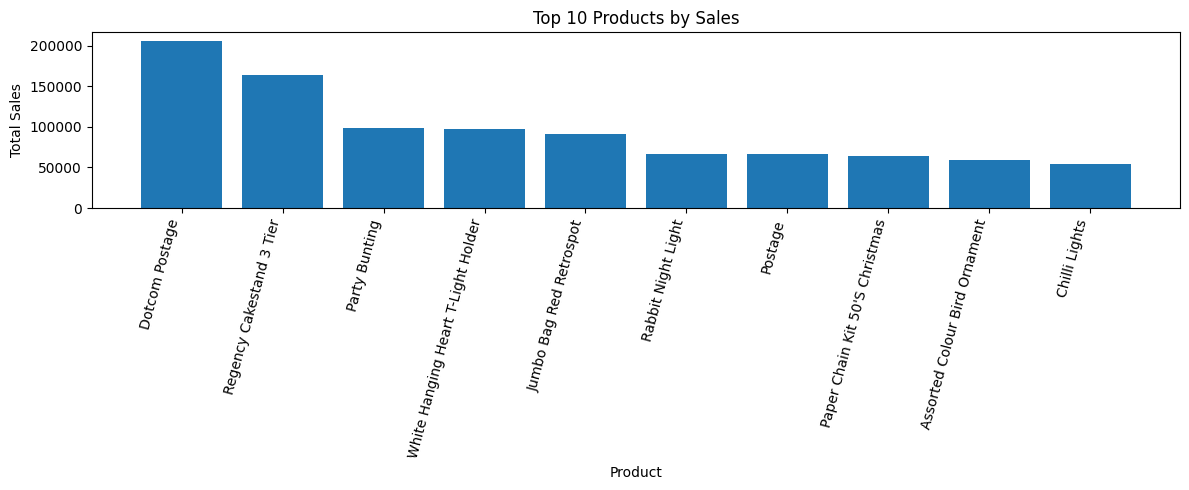

In [17]:
plt.figure(figsize=(12, 5))
plt.bar(top_products["description"], top_products["total_sales"])
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


## 13. Top 10 Customers by Sales

In [18]:
top_customers = (
    df[df["customerid"] != "N/A"]
    .groupby("customerid", as_index=False)
    .agg(total_sales=("sales_amount", "sum"),
         total_orders=("invoiceno", "nunique"))
    .sort_values("total_sales", ascending=False)
    .head(10)
)

top_customers


,customerid,total_sales,total_orders
1698,14646,279489.02,77
4219,18102,256438.49,62
3744,17450,187322.17,55
1890,14911,132458.73,248
54,12415,123725.45,26
1343,14156,113214.59,66
3787,17511,88125.38,46
3188,16684,65892.08,31
1003,13694,62690.54,60
2179,15311,59284.19,118


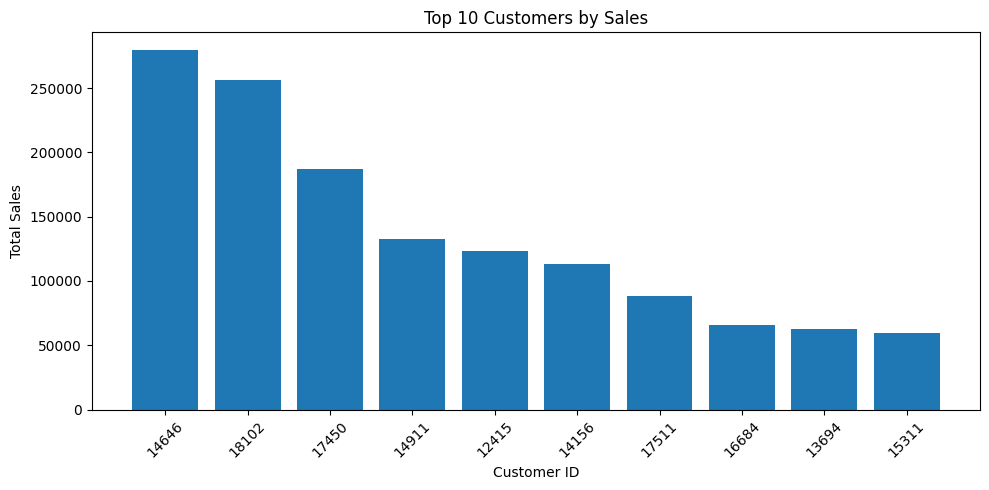

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(top_customers["customerid"], top_customers["total_sales"])
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 14. Sales Distribution

This helps identify extreme values and possible outliers.


In [20]:
df["sales_amount"].describe()


count    535383.000000
mean         18.117709
std         381.099975
min     -168469.600000
25%           3.750000
50%           9.870000
75%          17.400000
max      168469.600000
Name: sales_amount, dtype: float64

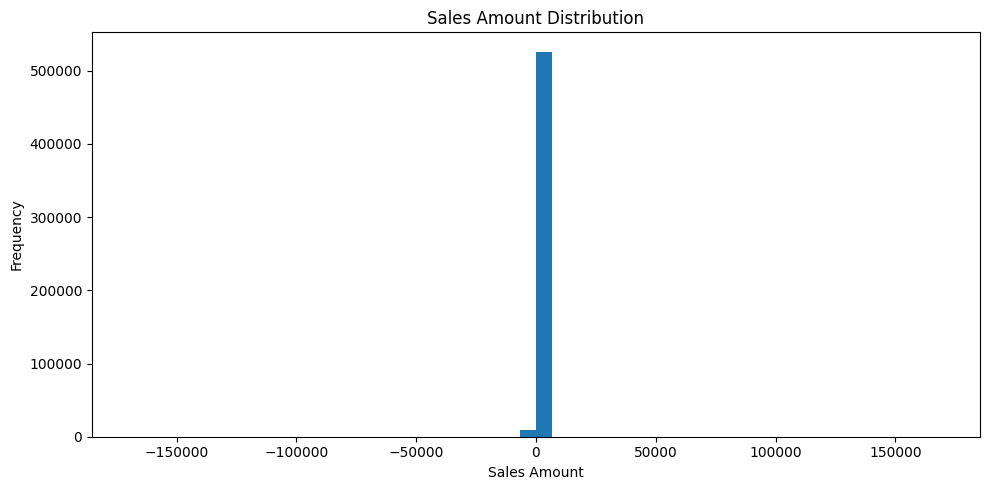

In [21]:
plt.figure(figsize=(10, 5))
plt.hist(df["sales_amount"], bins=50)
plt.title("Sales Amount Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 15. Non-Commercial or Special Records Review

This section helps validate whether records such as discounts, adjustments, samples, or postage are present before the transformation layer filters them.


In [22]:
keywords = [
    "POSTAGE", "TEST", "SAMPLE", "ADJUST", "DISCOUNT",
    "CHARGES", "CARRIAGE", "GIFT", "MANUAL",
    "UNKNOWN", "CHECK", "DAMAGED"
]

pattern = "|".join(keywords)

special_records = df[
    df["description"].astype(str).str.upper().str.contains(pattern, na=False)
]

print(f"Special records found: {len(special_records):,}")
special_records.head(10)


Special records found: 8,782


,invoiceno,stockcode,description,quantity,unitprice,invoicedate,customerid,country,sales_amount,invoice_date,year_month
30,536370,21883,Stars Gift Tape,24,0.65,2010-12-01 08:45:00,12583,France,15.60,2010-12-01,2010-12
45,536370,POST,Postage,3,18.00,2010-12-01 08:45:00,12583,France,54.00,2010-12-01,2010-12
141,C536379,D,Discount,-1,27.50,2010-12-01 09:41:00,14527,United Kingdom,-27.50,2010-12-01,2010-12
386,536403,POST,Postage,1,15.00,2010-12-01 11:27:00,12791,Netherlands,15.00,2010-12-01,2010-12
695,536425,22585,Pack Of 6 Birdy Gift Tags,12,1.25,2010-12-01 12:08:00,13758,United Kingdom,15.00,2010-12-01,2010-12
816,536464,22582,Pack Of 6 Sweetie Gift Boxes,1,2.55,2010-12-01 12:23:00,17968,United Kingdom,2.55,2010-12-01,2010-12
819,536464,22585,Pack Of 6 Birdy Gift Tags,3,1.25,2010-12-01 12:23:00,17968,United Kingdom,3.75,2010-12-01,2010-12
927,536520,21292,Small Stripes Chocolate Gift Bag,16,0.85,2010-12-01 12:43:00,14729,United Kingdom,13.60,2010-12-01,2010-12
965,536520,22582,Pack Of 6 Sweetie Gift Boxes,2,2.55,2010-12-01 12:43:00,14729,United Kingdom,5.10,2010-12-01,2010-12
966,536520,22583,Pack Of 6 Handbag Gift Boxes,3,2.55,2010-12-01 12:43:00,14729,United Kingdom,7.65,2010-12-01,2010-12


## 16. EDA Summary

Key findings to complete after running the notebook:

- Total revenue:
- Top country by sales:
- Top product by sales:
- Top customer by sales:
- Months with highest sales:
- Data quality issues identified:
- Records that should be excluded from the staging layer:

## Portfolio Note

This notebook supports the data pipeline by validating the cleaned dataset before the transformation and data warehouse stages.
